<a href="https://colab.research.google.com/github/VanNguyen-DA/Machine-Learning/blob/main/Final%20Project_Nguyen%20Thi%20Thanh%20Van_MachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.EDA & Processing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

import ipywidgets as widgets
from ipywidgets import interact, fixed
import calendar
import random

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving utils.py to utils.py


In [ ]:
import sys
sys.path.append("../")

from src.utils.utils import fill_missing_values, correct_outliers, add_template

In [ ]:
data = pd.read_csv('data.csv')
print(data.head())

  shipped_date     sku channel  qty   revenue  cost of good sold  MOQ order
0     1/1/2021  089A0E     ADS  190   5027.40            2926.00      56460
1     1/1/2021  089A0E     AWH   30    793.80                NaN      56460
2     1/1/2021  0FKFLA     AWH  780  32028.36           13104.00     427545
3     1/1/2021  0G8Z4M     AWH   85   1307.81             595.00       2516
4     1/1/2021  0NFJ14     FBM   38   2127.47            1723.25      18734


1. Overview Data

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48363 entries, 0 to 48362
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   shipped_date       48363 non-null  object 
 1   sku                48363 non-null  object 
 2   channel            48363 non-null  object 
 3   qty                48363 non-null  int64  
 4   revenue            44099 non-null  float64
 5   cost of good sold  43311 non-null  float64
 6   MOQ order          48363 non-null  int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 2.6+ MB


In [ ]:
data.rename(columns={'cost of good sold': 'COGS','MOQ order':'MOQ_orders'}, inplace=True)

In [ ]:
print(data.shape)
data.isna().sum()

(48363, 7)


,0
shipped_date,0
sku,0
channel,0
qty,0
revenue,4264
COGS,5052
MOQ_orders,0


2. Fill missing value

In [ ]:
data_filled = fill_missing_values(data)

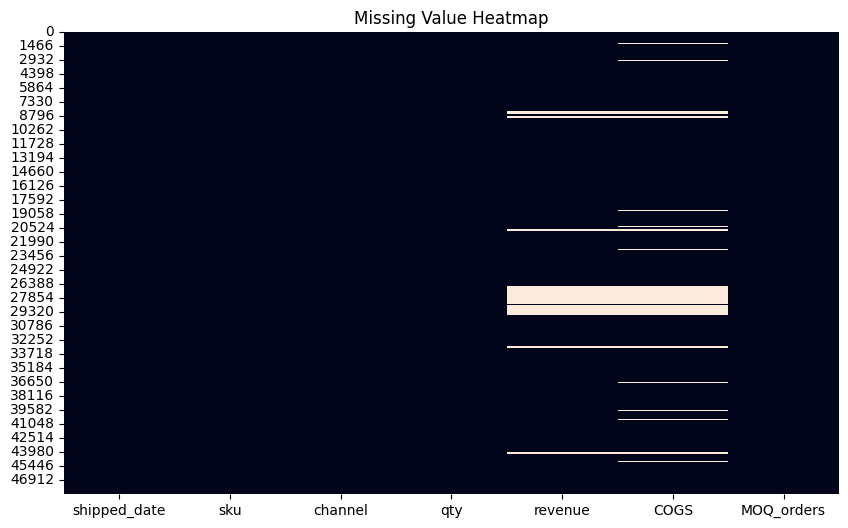

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(data.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

In [ ]:
data_filled.isna().sum()

,0
shipped_date,0
sku,0
channel,0
qty,0
revenue,28
COGS,0
MOQ_orders,0


In [ ]:
data_filled = data_filled.dropna(subset=['revenue'])

In [ ]:
data_filled.isna().sum()

,0
shipped_date,0
sku,0
channel,0
qty,0
revenue,0
COGS,0
MOQ_orders,0


In [ ]:
data_processed = data_filled[data_filled['qty'] >= 0]

EDA

In [ ]:
data_processed.shape

(48332, 7)

In [ ]:
data_processed.loc[(data_processed['qty']==0)&(data_processed['revenue']>0)]

,shipped_date,sku,channel,qty,revenue,COGS,MOQ_orders
26664,8/1/2021,6JRDWV,AWH,0,3484.251032,0,9880
26851,8/1/2021,SHA8AA,AWH,0,3383.033500,0,23436
26872,8/1/2021,UPYQYX,AWH,0,2014.630658,0,8550
26905,8/1/2021,XL7BBV,AWH,0,1322.895816,0,20553
26928,8/3/2021,089A0E,AWH,0,3330.799829,0,56460
26983,8/3/2021,6CZ34G,AWH,0,1497.346618,0,6138
26997,8/3/2021,8151BZ,ADS,0,1012.421667,0,322
27265,8/5/2021,6CZ34G,ADS,0,1497.346618,0,6138
27361,8/5/2021,K3KML2,AWH,0,3753.182619,0,82344
27386,8/5/2021,MR96NR,AWH,0,7172.297612,0,12000


In [ ]:
data_processed.loc[(data_processed['qty']>0)&(data_processed['revenue']==0)]

,shipped_date,sku,channel,qty,revenue,COGS,MOQ_orders


In [ ]:
data_processed = data_processed[~((data_processed['qty']==0)&(data_processed['revenue']>0))]
data_processed.shape

(48301, 7)

Check correlation

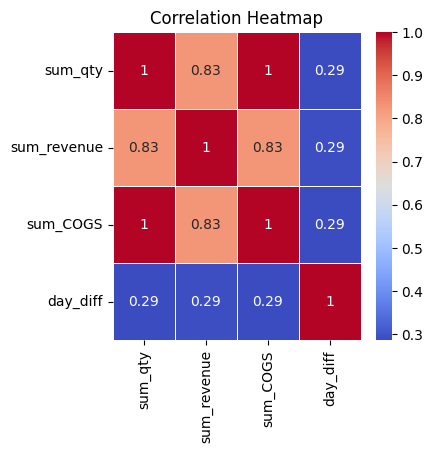

In [ ]:
data_processed['shipped_date'] = pd.to_datetime(data_processed['shipped_date'])
data_group = data_processed.groupby('sku').agg({'shipped_date': ['min', 'max'],
                                      'qty': 'sum',
                                      'revenue':'sum',
                                      'COGS':'sum'})


data_group.columns = ['min_date', 'max_date', 'sum_qty', 'sum_revenue', 'sum_COGS']
data_group['day_diff'] = (data_group['max_date'] - data_group['min_date']).dt.days
data_group = data_group.reset_index()
data_corr = data_group.corr(numeric_only=True)
plt.figure(figsize=(4, 4))
sns.heatmap(data_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
data_group['day_diff'] = (data_group['max_date'] - data_group['min_date']).dt.days
data_group['day_diff'].describe()

,day_diff
count,663.000000
mean,218.796380
std,144.831914
min,0.000000
25%,69.000000
50%,256.000000
75%,364.000000
max,366.000000


Choose top 20% SKUs that contribute most to revenue to forecast: (by the Pareto principle)

In [ ]:
data_group_sorted = data_group.sort_values(by='sum_revenue', ascending=False)
top_n = int(len(data_group_sorted) * 0.2)
top_20_percent_sku = data_group_sorted.head(top_n)['sku'].tolist()
print(len(top_20_percent_sku))

132


In [ ]:
data_group_sku = data.groupby(['shipped_date', 'sku']).agg({'qty': 'sum', 'revenue':'sum', 'COGS':'sum'}).reset_index()
data_forecast = data_group_sku[data_group_sku['sku'].isin(top_20_percent_sku)]
print(data_forecast.shape)
data_forecast.head()

(20905, 5)


,shipped_date,sku,qty,revenue,COGS
1,1/1/2021,0FKFLA,780,32028.36,13104.00
4,1/1/2021,11HSH1,150,7137.90,6209.97
5,1/1/2021,13KMDL,444,31048.92,8018.64
6,1/1/2021,17KYMH,966,54144.30,25411.60
9,1/1/2021,1JKADT,3038,46742.67,33627.72


Fill the data that not have fully in dataset:

In [ ]:
data_forecast['shipped_date'] = pd.to_datetime(data_forecast['shipped_date'])
data_forecast_template = add_template(data_forecast, min_date = data_forecast['shipped_date'].min(), max_date = data_forecast['shipped_date'].max(), skus = data_forecast['sku'].unique())
print(data_forecast_template.shape)
data_forecast_template.head(3)

(48444, 5)


,shipped_date,sku,qty,revenue,COGS
0,2021-01-01,0FKFLA,780.0,32028.36,13104.00
1,2021-01-01,11HSH1,150.0,7137.90,6209.97
2,2021-01-01,13KMDL,444.0,31048.92,8018.64


In [ ]:
def plot_daily_qty_for_month(data, month):

    data_month = data[data['month'] == month].copy()

    data_month['day'] = data_month['shipped_date'].dt.day

    list_sku_random = random.sample(data_month['sku'].unique().tolist(), 5)
    data_plot = data_month[data_month['sku'].isin(list_sku_random)]


    grouped = (data_plot.groupby(['sku', 'day'])['qty'].sum().reset_index())


    fig, ax = plt.subplots(figsize=(14, 6))
    for sku in sorted(grouped['sku'].unique()):
        sku_data = grouped[grouped['sku'] == sku]
        ax.plot(
            sku_data['day'],
            sku_data['qty'],
            marker='o',
            label=f'SKU {sku}'
        )

    ax.set_title(f'Daily Quantity - {calendar.month_name[month]}')
    ax.set_xlabel('Day of Month')
    ax.set_ylabel('Quantity')
    ax.grid(True)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    # plt.close(fig)
    # plt.show()

data_forecast_template['month'] = data_forecast_template['shipped_date'].dt.month
month_widget_ghi = widgets.Dropdown(options={calendar.month_name[m]: m for m in sorted(data_forecast_template["month"].unique()) if m != 0}, value=4, description="Month:")
# # interact(plot_daily_qty_for_month, data = data_forecast_template, month=month_widget_ghi)
interact(
    plot_daily_qty_for_month,
    data=fixed(data_forecast_template),
    month=month_widget_ghi
)

interactive(children=(Dropdown(description='Month:', index=3, options={'January': np.int32(1), 'February': np.…

<function __main__.plot_daily_qty_for_month(data, month)>

Add day features for easier to EDA

In [ ]:
data_forecast['month'] = data_forecast['shipped_date'].dt.month
data_forecast['day'] = data_forecast['shipped_date'].dt.day
data_forecast['dayofweek'] = data_forecast['shipped_date'].dt.dayofweek
data_forecast['weekofyear'] = data_forecast['shipped_date'].dt.isocalendar().week

data_forecast['is_even_day'] = (data_forecast['day'] % 2 == 0).astype(int)
print(data_forecast.head())

  shipped_date     sku   qty   revenue      COGS  month  day  dayofweek  \
1   2021-01-01  0FKFLA   780  32028.36  13104.00      1    1          4   
4   2021-01-01  11HSH1   150   7137.90   6209.97      1    1          4   
5   2021-01-01  13KMDL   444  31048.92   8018.64      1    1          4   
6   2021-01-01  17KYMH   966  54144.30  25411.60      1    1          4   
9   2021-01-01  1JKADT  3038  46742.67  33627.72      1    1          4   

   weekofyear  is_even_day  
1          53            0  
4          53            0  
5          53            0  
6          53            0  
9          53            0  


In [ ]:
data_plot = data_forecast[data_forecast['sku']=='1JKADT'].groupby(['month','is_even_day'])[['qty']].sum().reset_index()


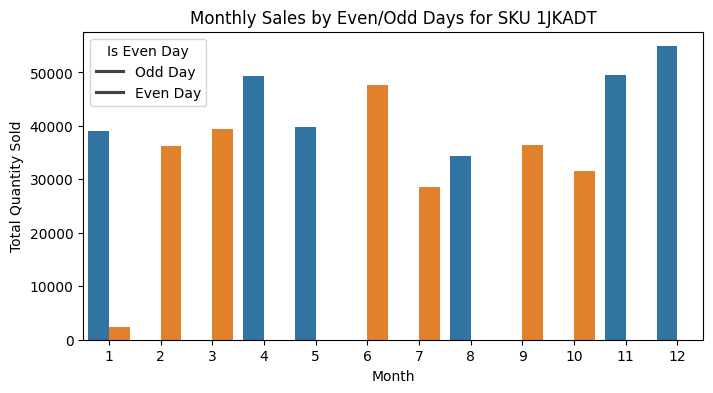

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=data_plot, x='month', y='qty', hue='is_even_day')
plt.title('Monthly Sales by Even/Odd Days for SKU 1JKADT')
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.legend(title='Is Even Day', labels=['Odd Day', 'Even Day'])
plt.show()

Check holiday effects

In [ ]:
holidays = [
    # New Year
    "2021-01-01",
    "2021-01-02",
    "2021-01-03",

    # Lunar New Year (Tet Holiday)
    "2021-02-10",
    "2021-02-11",
    "2021-02-12",
    "2021-02-13",
    "2021-02-14",
    "2021-02-15",
    "2021-02-16",

    # Hung Kings Commemoration Day
    "2021-04-21",

    # Reunification Day & International Workers' Day
    "2021-04-30",
    "2021-05-01",
    "2021-05-02",
    "2021-05-03",

    # National Day
    "2021-09-02",
    "2021-09-03",
    "2021-09-04",
    "2021-09-05",

    # Christmas (optional depending on business context)
    "2021-12-24",
    "2021-12-25",
]

holidays = pd.to_datetime(holidays)
data_forecast["is_holiday"] = data_forecast["shipped_date"].isin(holidays).astype(int)

data_forecast.head()

,shipped_date,sku,qty,revenue,COGS,month,day,dayofweek,weekofyear,is_even_day,is_holiday
1,2021-01-01,0FKFLA,780,32028.36,13104.00,1,1,4,53,0,1
4,2021-01-01,11HSH1,150,7137.90,6209.97,1,1,4,53,0,1
5,2021-01-01,13KMDL,444,31048.92,8018.64,1,1,4,53,0,1
6,2021-01-01,17KYMH,966,54144.30,25411.60,1,1,4,53,0,1
9,2021-01-01,1JKADT,3038,46742.67,33627.72,1,1,4,53,0,1


In [ ]:
data_forecast.groupby('is_holiday').agg({'qty': 'sum', 'sku':'count', 'COGS':'sum'}).reset_index()

,is_holiday,qty,sku,COGS
0,0,10231091,19534,1.994445e+08
1,1,695712,1371,1.426900e+07


Text(0.5, 1.0, 'Quantity Sold Over Time for Top 10 SKUs')

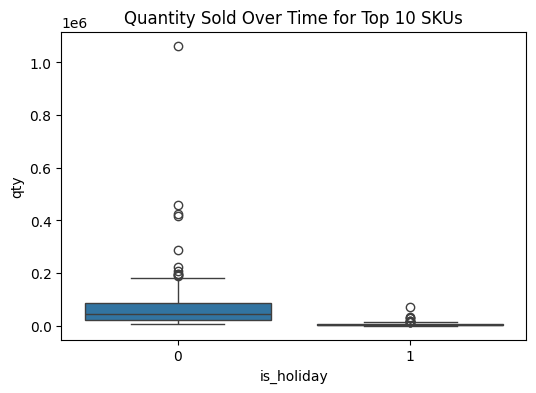

In [ ]:
data_plot = data_forecast.groupby(['sku', 'is_holiday']).agg({'qty': 'sum'}).reset_index()
plt.figure(figsize=(6, 4))
sns.boxplot(data=data_plot, x='is_holiday', y='qty')
plt.title('Quantity Sold Over Time for Top 10 SKUs')

Check quantity distribution:

In [ ]:
data_forecast["qty"].agg(["mean", "median", "skew", "kurt"])

,qty
mean,522.688496
median,256.000000
skew,6.118807
kurt,62.540597


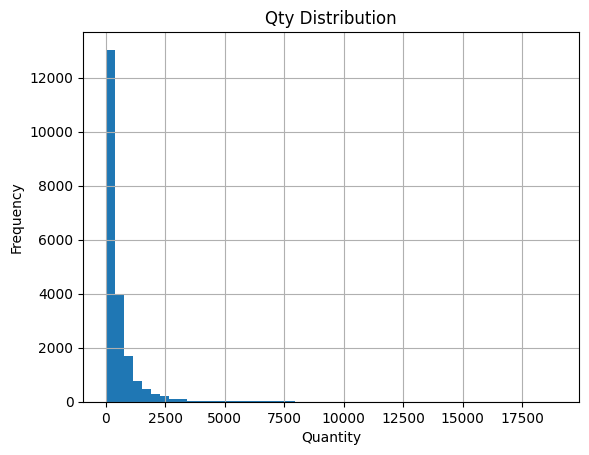

In [ ]:
data_forecast["qty"].hist(bins=50)
plt.title("Qty Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

Trend

In [ ]:
data_forecast.head(4)

,shipped_date,sku,qty,revenue,COGS,month,day,dayofweek,weekofyear,is_even_day,is_holiday
1,2021-01-01,0FKFLA,780,32028.36,13104.00,1,1,4,53,0,1
4,2021-01-01,11HSH1,150,7137.90,6209.97,1,1,4,53,0,1
5,2021-01-01,13KMDL,444,31048.92,8018.64,1,1,4,53,0,1
6,2021-01-01,17KYMH,966,54144.30,25411.60,1,1,4,53,0,1


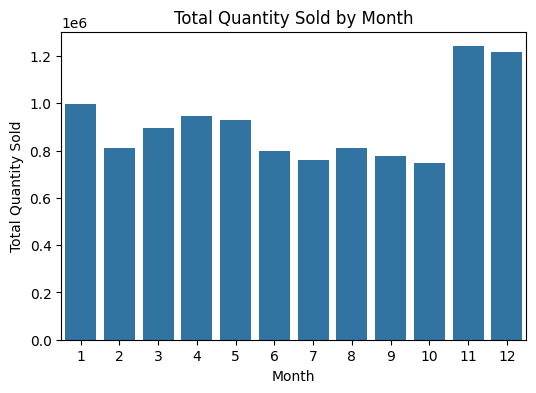

In [ ]:
data_plot = data_forecast.groupby('month')['qty'].sum().reset_index()
plt.figure(figsize=(6, 4))
sns.barplot(data=data_plot, x='month', y='qty')
plt.title('Total Quantity Sold by Month')
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.show()

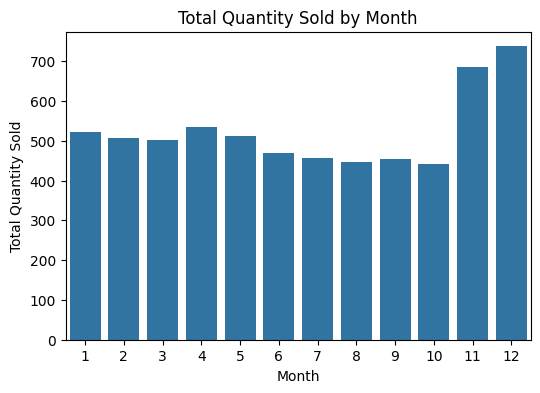

In [ ]:
data_plot = data_forecast.groupby('month')['qty'].mean().reset_index()
plt.figure(figsize=(6, 4))
sns.barplot(data=data_plot, x='month', y='qty')
plt.title('Total Quantity Sold by Month')
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.show()

In [ ]:
data_forecast.head()

,shipped_date,sku,qty,revenue,COGS,month,day,dayofweek,weekofyear,is_even_day,is_holiday
1,2021-01-01,0FKFLA,780,32028.36,13104.00,1,1,4,53,0,1
4,2021-01-01,11HSH1,150,7137.90,6209.97,1,1,4,53,0,1
5,2021-01-01,13KMDL,444,31048.92,8018.64,1,1,4,53,0,1
6,2021-01-01,17KYMH,966,54144.30,25411.60,1,1,4,53,0,1
9,2021-01-01,1JKADT,3038,46742.67,33627.72,1,1,4,53,0,1


Handle Outlier

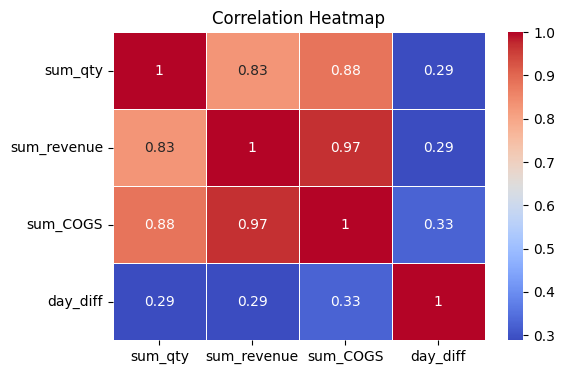

In [ ]:
data['shipped_date'] = pd.to_datetime(data['shipped_date'])
data_group = data.groupby('sku').agg({'shipped_date': ['min', 'max'],
                                      'qty': 'sum',
                                      'revenue':'sum',
                                      'COGS':'sum'})


data_group.columns = ['min_date', 'max_date', 'sum_qty', 'sum_revenue', 'sum_COGS']
data_group['day_diff'] = (data_group['max_date'] - data_group['min_date']).dt.days
data_group = data_group.reset_index()
data_corr = data_group.corr(numeric_only=True)
plt.figure(figsize=(6, 4))
sns.heatmap(data_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Before remove outliers: (48335, 7)


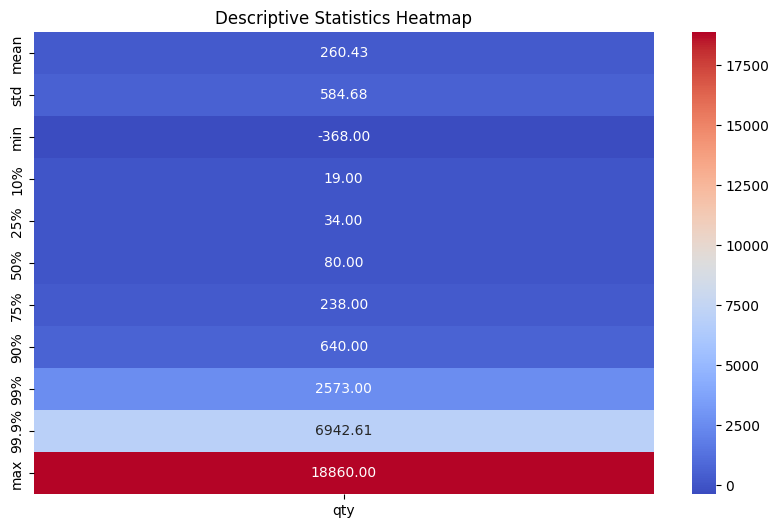

In [ ]:
print("Before remove outliers:",data_filled.shape)
summary = (
    data_filled[["sku", "qty"]]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999])
    .iloc[1:]
)

plt.figure(figsize=(10, 6))
sns.heatmap(summary, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Descriptive Statistics Heatmap")
plt.show()

In [ ]:
data_outliers_corrected = correct_outliers(data_filled, factor=3)

After remove outliers: (48335, 7)


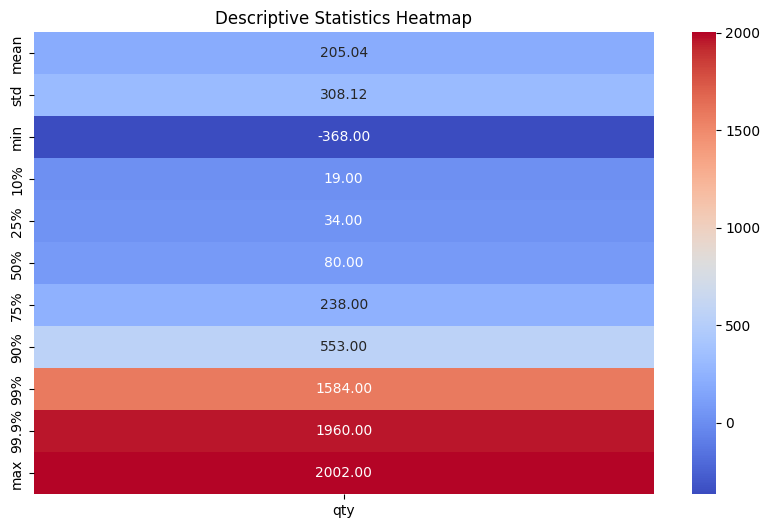

In [ ]:
print("After remove outliers:",data_outliers_corrected.shape)
summary = (
    data_outliers_corrected[["sku", "qty"]]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999])
    .iloc[1:]
)

plt.figure(figsize=(10, 6))
sns.heatmap(summary, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Descriptive Statistics Heatmap")
plt.show()

In [ ]:
data_processed = data_outliers_corrected[data_outliers_corrected['qty'] >= 0]

In [ ]:
print(data_processed.shape)
data_processed.head()

(48332, 7)


,shipped_date,sku,channel,qty,revenue,COGS,MOQ_orders
0,1/1/2021,089A0E,ADS,190.0,5027.40,190,56460
1,1/1/2021,089A0E,AWH,30.0,793.80,30,56460
2,1/1/2021,0FKFLA,AWH,780.0,32028.36,780,427545
3,1/1/2021,0G8Z4M,AWH,85.0,1307.81,85,2516
4,1/1/2021,0NFJ14,FBM,38.0,2127.47,38,18734


2. FEATURE ENGINEERING

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

import ipywidgets as widgets
from ipywidgets import interact, fixed
import calendar
import random
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data_processed.csv to data_processed.csv


In [ ]:
data = pd.read_csv('data_processed.csv')
print(data.head())

  shipped_date     sku channel    qty   revenue  COGS  MOQ_orders
0     1/1/2021  089A0E     ADS  190.0   5027.40   190       56460
1     1/1/2021  089A0E     AWH   30.0    793.80    30       56460
2     1/1/2021  0FKFLA     AWH  780.0  32028.36   780      427545
3     1/1/2021  0G8Z4M     AWH   85.0   1307.81    85        2516
4     1/1/2021  0NFJ14     FBM   38.0   2127.47    38       18734


Temporal and holiday features:

In [ ]:
def engineer_temporal_features(data):
    data['shipped_date'] = pd.to_datetime(data['shipped_date'])
    data['month'] = data['shipped_date'].dt.month
    data['day'] = data['shipped_date'].dt.day
    data['dayofweek'] = data['shipped_date'].dt.dayofweek
    data['weekofyear'] = data['shipped_date'].dt.isocalendar().week
    data['quarter']= data['shipped_date'].dt.quarter
    data['is_weekend'] = data['dayofweek'].isin([5, 6]).astype(int)

    data['is_even_day'] = (data['day'] % 2 == 0).astype(int) #because when EDA, we we found that some SKU only has sale on even day, so we add this feature to help model learn this pattern.
    return data

data_temp = engineer_temporal_features(data)
data_temp.head(4)

,shipped_date,sku,channel,qty,revenue,COGS,MOQ_orders,month,day,dayofweek,weekofyear,quarter,is_weekend,is_even_day
0,2021-01-01,089A0E,ADS,190.0,5027.40,190,56460,1,1,4,53,1,0,0
1,2021-01-01,089A0E,AWH,30.0,793.80,30,56460,1,1,4,53,1,0,0
2,2021-01-01,0FKFLA,AWH,780.0,32028.36,780,427545,1,1,4,53,1,0,0
3,2021-01-01,0G8Z4M,AWH,85.0,1307.81,85,2516,1,1,4,53,1,0,0


In [ ]:
holidays = [
    # New Year
    "2021-01-01",
    "2021-01-02",
    "2021-01-03",

    # Lunar New Year (Tet Holiday)
    "2021-02-10",
    "2021-02-11",
    "2021-02-12",
    "2021-02-13",
    "2021-02-14",
    "2021-02-15",
    "2021-02-16",

    # Hung Kings Commemoration Day
    "2021-04-21",

    # Reunification Day & International Workers' Day
    "2021-04-30",
    "2021-05-01",
    "2021-05-02",
    "2021-05-03",

    # National Day
    "2021-09-02",
    "2021-09-03",
    "2021-09-04",
    "2021-09-05",

    # Christmas (optional depending on business context)
    "2021-12-24",
    "2021-12-25",
]

holidays = pd.to_datetime(holidays)
data_temp["is_holiday"] = data_temp["shipped_date"].isin(holidays).astype(int)

data_temp.head()

,shipped_date,sku,channel,qty,revenue,COGS,MOQ_orders,month,day,dayofweek,weekofyear,quarter,is_weekend,is_even_day,is_holiday
0,2021-01-01,089A0E,ADS,190.0,5027.40,190,56460,1,1,4,53,1,0,0,1
1,2021-01-01,089A0E,AWH,30.0,793.80,30,56460,1,1,4,53,1,0,0,1
2,2021-01-01,0FKFLA,AWH,780.0,32028.36,780,427545,1,1,4,53,1,0,0,1
3,2021-01-01,0G8Z4M,AWH,85.0,1307.81,85,2516,1,1,4,53,1,0,0,1
4,2021-01-01,0NFJ14,FBM,38.0,2127.47,38,18734,1,1,4,53,1,0,0,1


Add features of SKU

In [ ]:
data_test = data_temp.copy()

data_test["shipped_date"] = pd.to_datetime(data_test["shipped_date"])
data_test = data_test.sort_values(["sku", "shipped_date"])

# the average sales of each SKU on the same day of the week (e.g., average sales of SKU A on Mondays, Tuesdays, etc.)
data_test["dow"] = data_test["shipped_date"].dt.weekday  # 0 = Monday

data_test["mean_qty_sku_dow"] = (
    data_test.groupby(["sku", "dow"])["qty"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

#the average sales of each SKU in the same month (e.g., average sales of SKU A in January, February, etc.)
data_test["month"] = data_test["shipped_date"].dt.month

data_test["mean_qty_sku_month"] = (
    data_test.groupby(["sku", "month"])["qty"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

data_test['mean_qty_sku_dow'].fillna(data_test.groupby('sku')['qty'].transform(lambda x: x.shift(1).expanding().mean()), inplace=True)
data_test['mean_qty_sku_month'].fillna(data_test.groupby('sku')['qty'].transform(lambda x: x.shift(1).expanding().mean()), inplace=True)


data_test['mean_qty_sku_dow'].fillna(0, inplace=True)
data_test['mean_qty_sku_month'].fillna(0, inplace=True)

Transform qty to log(qty) to avoid scale with 0:

In [ ]:
data_model = data_test.copy()
data_model["qty_log"] = np.log1p(data_model["qty"])  # log(1 + qty)

data_model['qty_log'].describe()

,qty_log
count,48332.000000
mean,4.527572
std,1.268110
min,0.000000
25%,3.555348
50%,4.394449
75%,5.476464
max,7.602401


Add lag and moving_average features:

In [ ]:
data_final = data_model.copy()

data_final['lag1'] = data_final.groupby('sku')['qty'].shift(1)
data_final['lag7'] = data_final.groupby('sku')['qty'].shift(7)
data_final['lag30'] = data_final.groupby('sku')['qty'].shift(30)
data_final['rolling_mean_7'] = data_final.groupby('sku')['qty'].transform(lambda x: x.rolling(window=7,min_periods=1).mean())
data_final['rolling_mean_30'] = data_final.groupby('sku')['qty'].transform(lambda x: x.rolling(window=30,min_periods=1).mean())
data_final['rolling_std_7'] = data_final.groupby('sku')['qty'].transform(lambda x: x.rolling(window=7,min_periods=1).std())
data_final['rolling_std_30'] = data_final.groupby('sku')['qty'].transform(lambda x: x.rolling(window=30,min_periods=1).std())

data_final.head()

,shipped_date,sku,channel,qty,revenue,COGS,MOQ_orders,month,day,dayofweek,...,mean_qty_sku_dow,mean_qty_sku_month,qty_log,lag1,lag7,lag30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30
335,2021-01-03,017SAD,ADS,75.0,3358.95,75,1425,1,3,6,...,0.0,0.0,4.330733,NaN,NaN,NaN,75.0,75.0,NaN,NaN
1642,2021-01-15,017SAD,ADS,75.0,3358.95,75,1425,1,15,4,...,75.0,75.0,4.330733,75.0,NaN,NaN,75.0,75.0,0.0,0.0
5711,2021-02-16,017SAD,ADS,75.0,3358.95,75,1425,2,16,1,...,75.0,75.0,4.330733,75.0,NaN,NaN,75.0,75.0,0.0,0.0
5712,2021-02-16,017SAD,LAL,75.0,2310.00,75,1425,2,16,1,...,75.0,75.0,4.330733,75.0,NaN,NaN,75.0,75.0,0.0,0.0
6862,2021-02-26,017SAD,ADS,75.0,3358.95,75,1425,2,26,4,...,75.0,75.0,4.330733,75.0,NaN,NaN,75.0,75.0,0.0,0.0


In [ ]:
data_final.head(4)

,shipped_date,sku,channel,qty,revenue,COGS,MOQ_orders,month,day,dayofweek,...,mean_qty_sku_dow,mean_qty_sku_month,qty_log,lag1,lag7,lag30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30
335,2021-01-03,017SAD,ADS,75.0,3358.95,75,1425,1,3,6,...,0.0,0.0,4.330733,NaN,NaN,NaN,75.0,75.0,NaN,NaN
1642,2021-01-15,017SAD,ADS,75.0,3358.95,75,1425,1,15,4,...,75.0,75.0,4.330733,75.0,NaN,NaN,75.0,75.0,0.0,0.0
5711,2021-02-16,017SAD,ADS,75.0,3358.95,75,1425,2,16,1,...,75.0,75.0,4.330733,75.0,NaN,NaN,75.0,75.0,0.0,0.0
5712,2021-02-16,017SAD,LAL,75.0,2310.00,75,1425,2,16,1,...,75.0,75.0,4.330733,75.0,NaN,NaN,75.0,75.0,0.0,0.0


3. APPLYING MODEL

In [ ]:
!pip install optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

# Model
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgbm
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
from xgboost import XGBRegressor

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

import joblib

import shap
import optuna
import os
import pickle
import json

np.random.seed(2025)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 24.8 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data_engineered.csv to data_engineered.csv


In [ ]:
data = pd.read_csv('data_engineered.csv')
print(data.head(4))

  shipped_date     sku channel   qty  revenue  COGS  MOQ_orders  month  day  \
0   2021-01-03  017SAD     ADS  75.0  3358.95    75        1425      1    3   
1   2021-01-15  017SAD     ADS  75.0  3358.95    75        1425      1   15   
2   2021-02-16  017SAD     ADS  75.0  3358.95    75        1425      2   16   
3   2021-02-16  017SAD     LAL  75.0  2310.00    75        1425      2   16   

   dayofweek  ...  mean_qty_sku_dow  mean_qty_sku_month   qty_log  lag1  lag7  \
0          6  ...               0.0                 0.0  4.330733   NaN   NaN   
1          4  ...              75.0                75.0  4.330733  75.0   NaN   
2          1  ...              75.0                75.0  4.330733  75.0   NaN   
3          1  ...              75.0                75.0  4.330733  75.0   NaN   

   lag30  rolling_mean_7  rolling_mean_30  rolling_std_7  rolling_std_30  
0    NaN            75.0             75.0            NaN             NaN  
1    NaN            75.0             75.0       

In [ ]:
import sys
sys.path.append("../")

from src.utils.utils import fill_missing_values, correct_outliers, add_template, weighted_absolute_percentage_error

Split train/test:

In [ ]:
data_model = data.sort_values("shipped_date")

split_idx = int(len(data_model) * 0.8)

train = data_model.iloc[:split_idx]
test  = data_model.iloc[split_idx:]
print(train.shape)
print(test.shape)

(38665, 26)
(9667, 26)


In [ ]:
X_train = train.drop(columns=["qty_log"])
y_train = train["qty_log"]

X_test = test.drop(columns=["qty_log"])
y_test = test["qty_log"]

In [ ]:
X_train = X_train.drop(columns=["qty","shipped_date", "sku","revenue","COGS"])
X_test = X_test.drop(columns=["qty","shipped_date", "sku","revenue","COGS"])

Apply the model:

Random Forest (baseline)

In [ ]:
categorical_features = ['channel']
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ],
    remainder='drop'
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_processed, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test_processed)
y_pred_rf_exp = np.expm1(y_pred_rf)

In [ ]:
r2 = r2_score(np.expm1(y_test), y_pred_rf_exp)
mae = mean_absolute_error(np.expm1(y_test), y_pred_rf_exp)
rmse = np.sqrt(mean_squared_error(np.expm1(y_test), y_pred_rf_exp))
wape = weighted_absolute_percentage_error(np.expm1(y_test), y_pred_rf_exp)
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"WMAPE: {wape:.4f}")

R²: 0.6074
MAE: 107.8506
RMSE: 208.7828
WMAPE: 46.4207


In [ ]:
test['qty_pred'] = y_pred_rf_exp

Evaluate on each SKU:

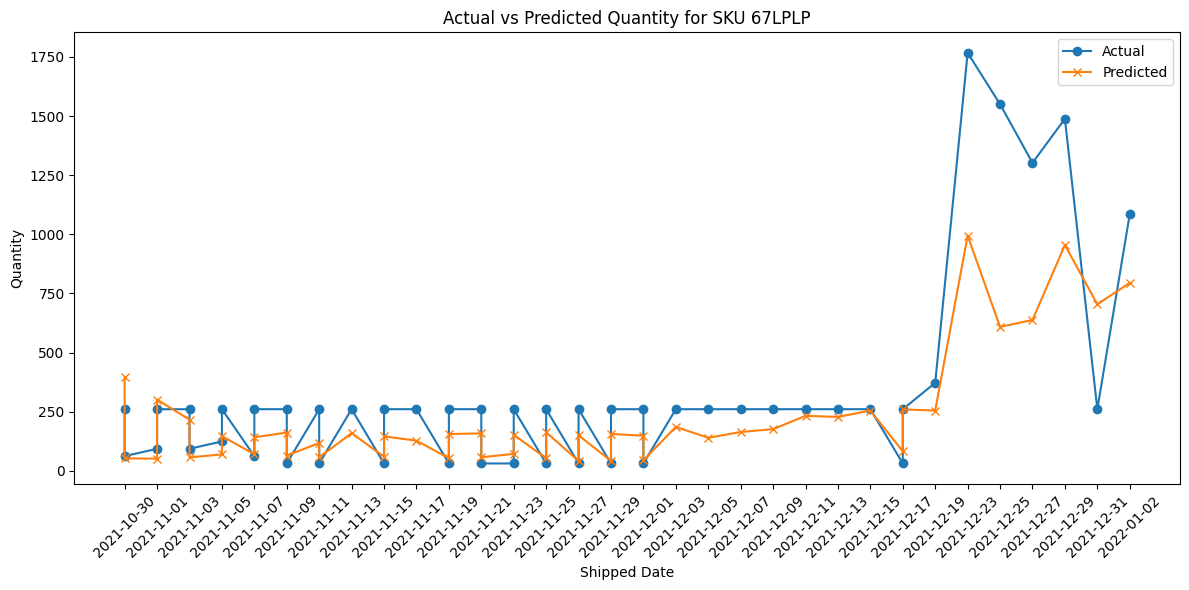

In [ ]:
plot_df = test[test['sku'] == '4OCITK']
plt.figure(figsize=(12, 6))
plt.plot(plot_df['shipped_date'], plot_df['qty'], label='Actual', marker='o')
plt.plot(plot_df['shipped_date'], plot_df['qty_pred'], label='Predicted', marker='x')
plt.title('Actual vs Predicted Quantity for SKU 67LPLP')
plt.xlabel('Shipped Date')
plt.ylabel('Quantity')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Build LightGBM model

In [ ]:
def create_lightgbm_model(X_train, y_train, X_test, y_test):
    """
    Create a LightGBM model using engineered features
    """
    print("\nCreating base lightgbm model...")

    # Use a time series split for validation within the training set
    # This ensures we're always validating on future data
    tscv = TimeSeriesSplit(n_splits=5)

    # Basic LightGBM parameters
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "num_leaves": 31,
        "learning_rate": 0.05,
        "feature_fraction": 0.9,
        "n_estimators": 100,
        "verbose": -1,
    }

    # Train the model with cross-validation on training data only
    cv_scores = []

    for train_idx, val_idx in tscv.split(X_train):
        X_train_cv, X_val_cv = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Train the model
        model = lgbm.LGBMRegressor(**params)
        model.fit(
            X_train_cv,
            y_train_cv,
            eval_set=[(X_val_cv, y_val_cv)],
            # early_stopping_rounds=50,
            # verbose=False
        )

        # Make predictions
        preds = model.predict(X_val_cv)

        # Calculate metrics
        mae = mean_absolute_error(y_val_cv, preds)
        rmse = np.sqrt(mean_squared_error(y_val_cv, preds))
        wape = weighted_absolute_percentage_error(y_val_cv, preds)

        cv_scores.append((mae, rmse, wape))

    # Print average scores from cross-validation
    mae_avg, rmse_avg, wape_avg = np.mean(cv_scores, axis=0)
    print(
        f"Baseline Model CV - MAE: {mae_avg:.2f}, RMSE: {rmse_avg:.2f}, WAPE: {wape_avg:.2f}%"
    )

    # Train a final model on all training data
    final_model = lgbm.LGBMRegressor(**params)
    final_model.fit(X_train, y_train)

    # Evaluate on the test set (last 3 months of 2017)
    test_preds = final_model.predict(X_test)
    test_mae = mean_absolute_error(y_test, test_preds)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    test_wape = weighted_absolute_percentage_error(y_test, test_preds)

    print(
        f"Baseline Model Test - MAE: {test_mae:.2f}, RMSE: {test_rmse:.2f}, WAPE: {test_wape:.2f}%"
    )

    return final_model, (test_mae, test_rmse, test_wape)

In [ ]:
X_train['channel'] = X_train['channel'].astype('category')
X_test['channel'] = X_test['channel'].astype('category')

lightgbm_model, lightgbm_metrics = create_lightgbm_model(
    X_train, y_train, X_test, y_test
)


Creating base lightgbm model...
Baseline Model CV - MAE: 0.45, RMSE: 0.62, WAPE: 10.05%
Baseline Model Test - MAE: 0.55, RMSE: 0.77, WAPE: 11.76%


Optuna for tuning LightGBM model:

In [ ]:
def optimize_lightgbm(X_train, y_train, X_test, y_test):
    """
    Optimize LightGBM model using Optuna
    """

    print("\nOptimizing LightGBM model with Optuna...")

    def objective(trial):
        """Optuna objective function for LightGBM optimization"""
        params = {
            "objective": "regression",
            "metric": " wmape",
            "boosting_type": "gbdt",
            "num_leaves": trial.suggest_int("num_leaves", 15, 50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01 , 0.1),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.7, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.7, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 30),
            # "n_estimators": trial.suggest_int("n_estimators", 500),
            "n_estimators": 500,
            "verbose": -1,
        }

        # Train with early stopping
        model = lgbm.LGBMRegressor(**params)
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_test, y_test)],
            callbacks=[lgbm.early_stopping(stopping_rounds=20)],
            # verbose=False,
        )

        # Predict and calculate RMSE
        preds = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        wmape = weighted_absolute_percentage_error(y_test, preds)

        return wmape

    # Create and run study
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=50)  # In practice, use more trials

    # Get best parameters
    best_params = study.best_params
    best_params.update(
        {
            "objective": "regression",
            "metric": "wmape",
            "boosting_type": "gbdt",
            "verbose": -1,
        }
    )

    print("Best LightGBM parameters found:")
    for key, value in best_params.items():
        print(f"    {key}: {value}")

    # Train final model with best parameters
    final_model = lgbm.LGBMRegressor(**best_params)
    final_model.fit(X_train, y_train)

    # Make predictions
    test_preds = final_model.predict(X_test)

    # Calculate metrics
    test_mae = mean_absolute_error(y_test, test_preds)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    test_wape = weighted_absolute_percentage_error(y_test, test_preds)

    print(
        f"Optimized LightGBM Test Metrics - MAE: {test_mae:.2f}, RMSE: {test_rmse:.2f}, WAPE: {test_wape:.2f}%"
    )

    return final_model, test_preds, (test_mae, test_rmse, test_wape)

In [ ]:
optimized_model, best_params, optimized_metrics = optimize_lightgbm(
    X_train, y_train, X_test, y_test
)

[I 2026-08-13 11:46:19,157] A new study created in memory with name: no-name-c5d50cd5-235c-47b2-8450-db4586436e6a



Optimizing LightGBM model with Optuna...
Training until validation scores don't improve for 20 rounds


[I 2026-08-13 11:46:20,815] Trial 0 finished with value: 11.656112894137536 and parameters: {'num_leaves': 32, 'learning_rate': 0.09291533417569037, 'feature_fraction': 0.7950132743590757, 'bagging_fraction': 0.9745161756299685, 'bagging_freq': 6, 'min_child_samples': 12}. Best is trial 0 with value: 11.656112894137536.


Early stopping, best iteration is:
[170]	valid_0's l2: 0.57617
Training until validation scores don't improve for 20 rounds


[I 2026-08-13 11:46:23,138] Trial 1 finished with value: 11.829562099799187 and parameters: {'num_leaves': 48, 'learning_rate': 0.0387885935433763, 'feature_fraction': 0.757205465176942, 'bagging_fraction': 0.8226818008244718, 'bagging_freq': 5, 'min_child_samples': 15}. Best is trial 0 with value: 11.656112894137536.


...

Early stopping, best iteration is:
[160]	valid_0's l2: 0.583782
Training until validation scores don't improve for 20 rounds


[I 2026-08-13 11:48:00,804] Trial 48 finished with value: 11.693893383984298 and parameters: {'num_leaves': 29, 'learning_rate': 0.04753807106676259, 'feature_fraction': 0.876236593562139, 'bagging_fraction': 0.8357619932345594, 'bagging_freq': 1, 'min_child_samples': 8}. Best is trial 5 with value: 11.486410253667268.


Early stopping, best iteration is:
[85]	valid_0's l2: 0.590026
Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[499]	valid_0's l2: 0.571549


[I 2026-08-13 11:48:04,685] Trial 49 finished with value: 11.558011080621782 and parameters: {'num_leaves': 21, 'learning_rate': 0.03409355610528607, 'feature_fraction': 0.978669469382595, 'bagging_fraction': 0.9616804071954638, 'bagging_freq': 3, 'min_child_samples': 17}. Best is trial 5 with value: 11.486410253667268.


Best LightGBM parameters found:
    num_leaves: 47
    learning_rate: 0.08684866766904761
    feature_fraction: 0.9642421106262642
    bagging_fraction: 0.876412409131347
    bagging_freq: 4
    min_child_samples: 14
    objective: regression
    metric: wmape
    boosting_type: gbdt
    verbose: -1
Optimized LightGBM Test Metrics - MAE: 0.54, RMSE: 0.76, WAPE: 11.55%


Evaluating model

In [ ]:
def evaluate_model(model, X_test, y_test, data):
    """
    Evaluate the model performance on the test set (last 3 months of 2017)
    """
    print("\nEvaluating model performance on test set...")

    # Make predictions on the test set
    test_preds = model.predict(X_test)

    # Calculate metrics
    test_mae = mean_absolute_error(y_test, test_preds)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    test_wape = weighted_absolute_percentage_error(y_test, test_preds)

    # Print evaluation results
    print(f"Final Model Test Evaluation:")
    print(f"    MAE: {test_mae:.2f}")
    print(f"    RMSE: {test_rmse:.2f}")
    print(f"    WAPE: {test_wape:.2f}%")

    # Analyze errors by time period (month)
    test_results = test.copy()
    test_results['shipped_date'] = pd.to_datetime(test_results['shipped_date'])
    test_results["prediction"] = test_preds
    test_results["error"] = test_results["qty"] - test_results["prediction"]
    test_results["abs_error"] = np.abs(test_results["error"])
    test_results["month_name"] = test_results["shipped_date"].dt.strftime("%B")

    # Summarize errors by month
    monthly_errors = (
        test_results.groupby("month_name")
        .agg({"abs_error": "mean", "error": "mean", "qty": "mean"})
        .reset_index()
    )
    monthly_errors["error_pct"] = (
        100 * monthly_errors["abs_error"] / monthly_errors["qty"]
    )

    print("\nError Analysis by Month:")
    print(
        monthly_errors[["month_name", "abs_error", "error_pct"]].to_string(index=False)
    )

    # Store results for visualization
    # Include month and store information for granular analysis
    test_results["year_month"] = test_results["shipped_date"].dt.strftime("%Y-%m")

    # Plot actual vs predicted
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, test_preds, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], "r--")
    plt.title("Actual vs Predicted Sales (Test Set)")
    plt.xlabel("Actual Sales")
    plt.ylabel("Predicted Sales")
    plt.tight_layout()
    # plt.savefig('actual_vs_predicted_test.png')

    # Plot error distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(test_results["error"], kde=True)
    plt.title("Error Distribution")
    plt.xlabel("Prediction Error")
    plt.tight_layout()
    # plt.savefig('error_distribution.png')

    return test_mae, test_rmse, test_wape, test_preds, y_test, test_results


Evaluating model performance on test set...
Final Model Test Evaluation:
    MAE: 0.55
    RMSE: 0.77
    WAPE: 11.76%

Error Analysis by Month:
month_name  abs_error  error_pct
  December 241.349643  98.155647
   January 194.336465  97.515624
  November 218.454517  98.008924
   October 209.137019  97.962374


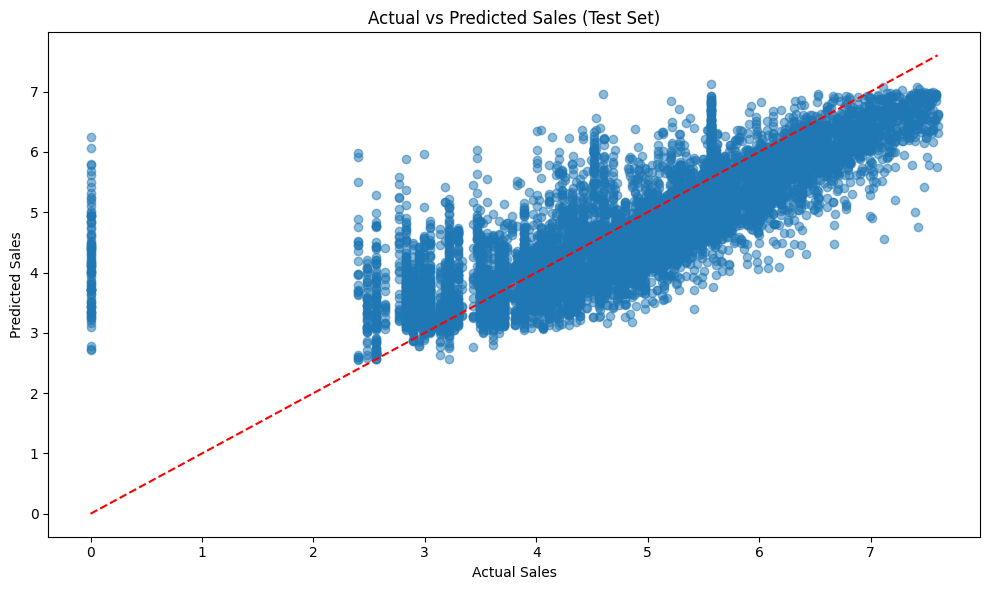

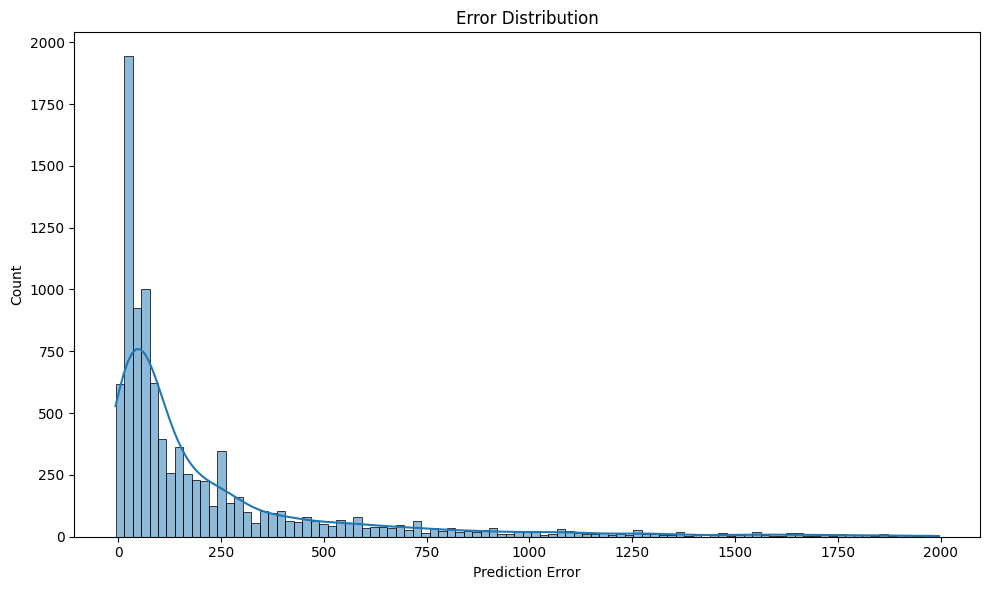

In [ ]:
test_mae, test_rmse, test_smape, test_preds, y_test_values, test_results = (
    evaluate_model(lightgbm_model, X_test, y_test, test)
)

Save model

In [ ]:
def save_model(model, X_train, feature_names, output_dir="../models"):
    """
    Save the trained model and related artifacts for API use

    Args:
        model: Trained model (e.g., LightGBM model)
        feature_names: List of feature names
        output_dir: Directory to save model artifacts
    """

    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Save the model
    model_path = os.path.join(output_dir, "sales_forecast_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(model, f)
    print(f"Model saved to {model_path}")

    # Create and save feature statistics
    feature_stats = {
        "model_version": "1.0.0",
        "last_trained": pd.Timestamp.now().strftime("%Y-%m-%d"),
        "required_columns": list(feature_names),
        "column_order": list(feature_names),
        "default_values": {},
    }

    # Add default values for date features
    feature_stats["default_values"] = {
        "year": 2017,
        "month": 11,
        "day": 15,
        "day_of_week": 2,
        "is_weekend": 0,
        "quarter": 4,
        "is_holiday": 0,
    }

    # Save feature stats
    stats_path = os.path.join(output_dir, "feature_stats.json")
    with open(stats_path, "w") as f:
        json.dump(feature_stats, f, indent=4)
    print(f"Feature statistics saved to {stats_path}")

    print(f"All model artifacts saved successfully to {output_dir}/")

    return model_path, stats_path

In [ ]:
save_model(
    model=optimized_model,
    X_train=X_train,
    feature_names=X_train.columns,
    output_dir='../models'
)

Model saved to ../models/sales_forecast_model.pkl
Feature statistics saved to ../models/feature_stats.json
All model artifacts saved successfully to ../models/


('../models/sales_forecast_model.pkl', '../models/feature_stats.json')

4. EXPLAINING MODEL

In [ ]:
import json
import os
import pickle
import sys
import warnings
from datetime import datetime, timedelta

import lightgbm as lgbm
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore")
import math

# Set plotting style
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

# Set random seed for reproducibility
np.random.seed(2025)

In [ ]:
import sys
sys.path.append("../")

from src.utils.utils import load_model, plot_sku_forecast

Load model and data:

In [ ]:
model_path = ".././models/sales_forecast_model.pkl"
model = load_model(model_path)

Sklearn model loaded from .././models/sales_forecast_model.pkl


In [ ]:
data = pd.read_csv('data_engineered.csv')
data.head(3)

,shipped_date,sku,channel,qty,revenue,COGS,MOQ_orders,month,day,dayofweek,...,mean_qty_sku_dow,mean_qty_sku_month,qty_log,lag1,lag7,lag30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30
0,2021-01-03,017SAD,ADS,75.0,3358.95,75,1425,1,3,6,...,0.0,0.0,4.330733,NaN,NaN,NaN,75.0,75.0,NaN,NaN
1,2021-01-15,017SAD,ADS,75.0,3358.95,75,1425,1,15,4,...,75.0,75.0,4.330733,75.0,NaN,NaN,75.0,75.0,0.0,0.0
2,2021-02-16,017SAD,ADS,75.0,3358.95,75,1425,2,16,1,...,75.0,75.0,4.330733,75.0,NaN,NaN,75.0,75.0,0.0,0.0


In [ ]:
data_model = data.sort_values("shipped_date")

split_idx = int(len(data_model) * 0.8)

train = data_model.iloc[:split_idx]
test  = data_model.iloc[split_idx:]
print(train.shape)
print(test.shape)

X_train = train.drop(columns=["qty_log"])
y_train = train["qty_log"]

X_test = test.drop(columns=["qty_log"])
y_test = test["qty_log"]

X_train = X_train.drop(columns=["qty","shipped_date", "sku","revenue","COGS"])
X_test = X_test.drop(columns=["qty","shipped_date", "sku","revenue","COGS"])

(38665, 26)
(9667, 26)


In [ ]:
test.head()

,shipped_date,sku,channel,qty,revenue,COGS,MOQ_orders,month,day,dayofweek,...,mean_qty_sku_dow,mean_qty_sku_month,qty_log,lag1,lag7,lag30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30
9660,2021-10-30,6CZ34G,ADS,44.0,2255.64,44,6138,10,30,5,...,24.750000,23.375,3.806662,11.0,22.0,55.0,25.142857,26.766667,19.794179,17.496174
17465,2021-10-30,C5GM9N,ADS,24.0,318.86,24,1944,10,30,5,...,48.000000,48.000,3.218876,72.0,NaN,NaN,40.000000,40.000000,27.712813,27.712813
25919,2021-10-30,JLZPTV,ADS,182.0,4074.25,182,74256,10,30,5,...,411.894737,254.800,5.209486,91.0,455.0,182.0,234.000000,254.800000,222.017267,161.022037
25920,2021-10-30,JLZPTV,AWH,91.0,2037.13,91,74256,10,30,5,...,400.400000,250.250,4.521789,182.0,182.0,273.0,221.000000,248.733333,228.149074,163.718626
40147,2021-10-30,UPJIR1,FBA,12.0,206.47,12,20628,10,30,5,...,33.428571,36.000,2.564949,72.0,36.0,24.0,29.142857,30.000000,21.751847,22.227662


Predict and evaluation:

In [ ]:
X_test['channel'] = X_test['channel'].astype('category')
test["prediction"] = np.expm1(model.predict(X_test))
test["error"] = test["qty"] - test["prediction"]
test["abs_error"] = np.abs(test["error"])
df_prediction = test[
    ["shipped_date", "sku", "qty", "month", "quarter", "prediction"]
]

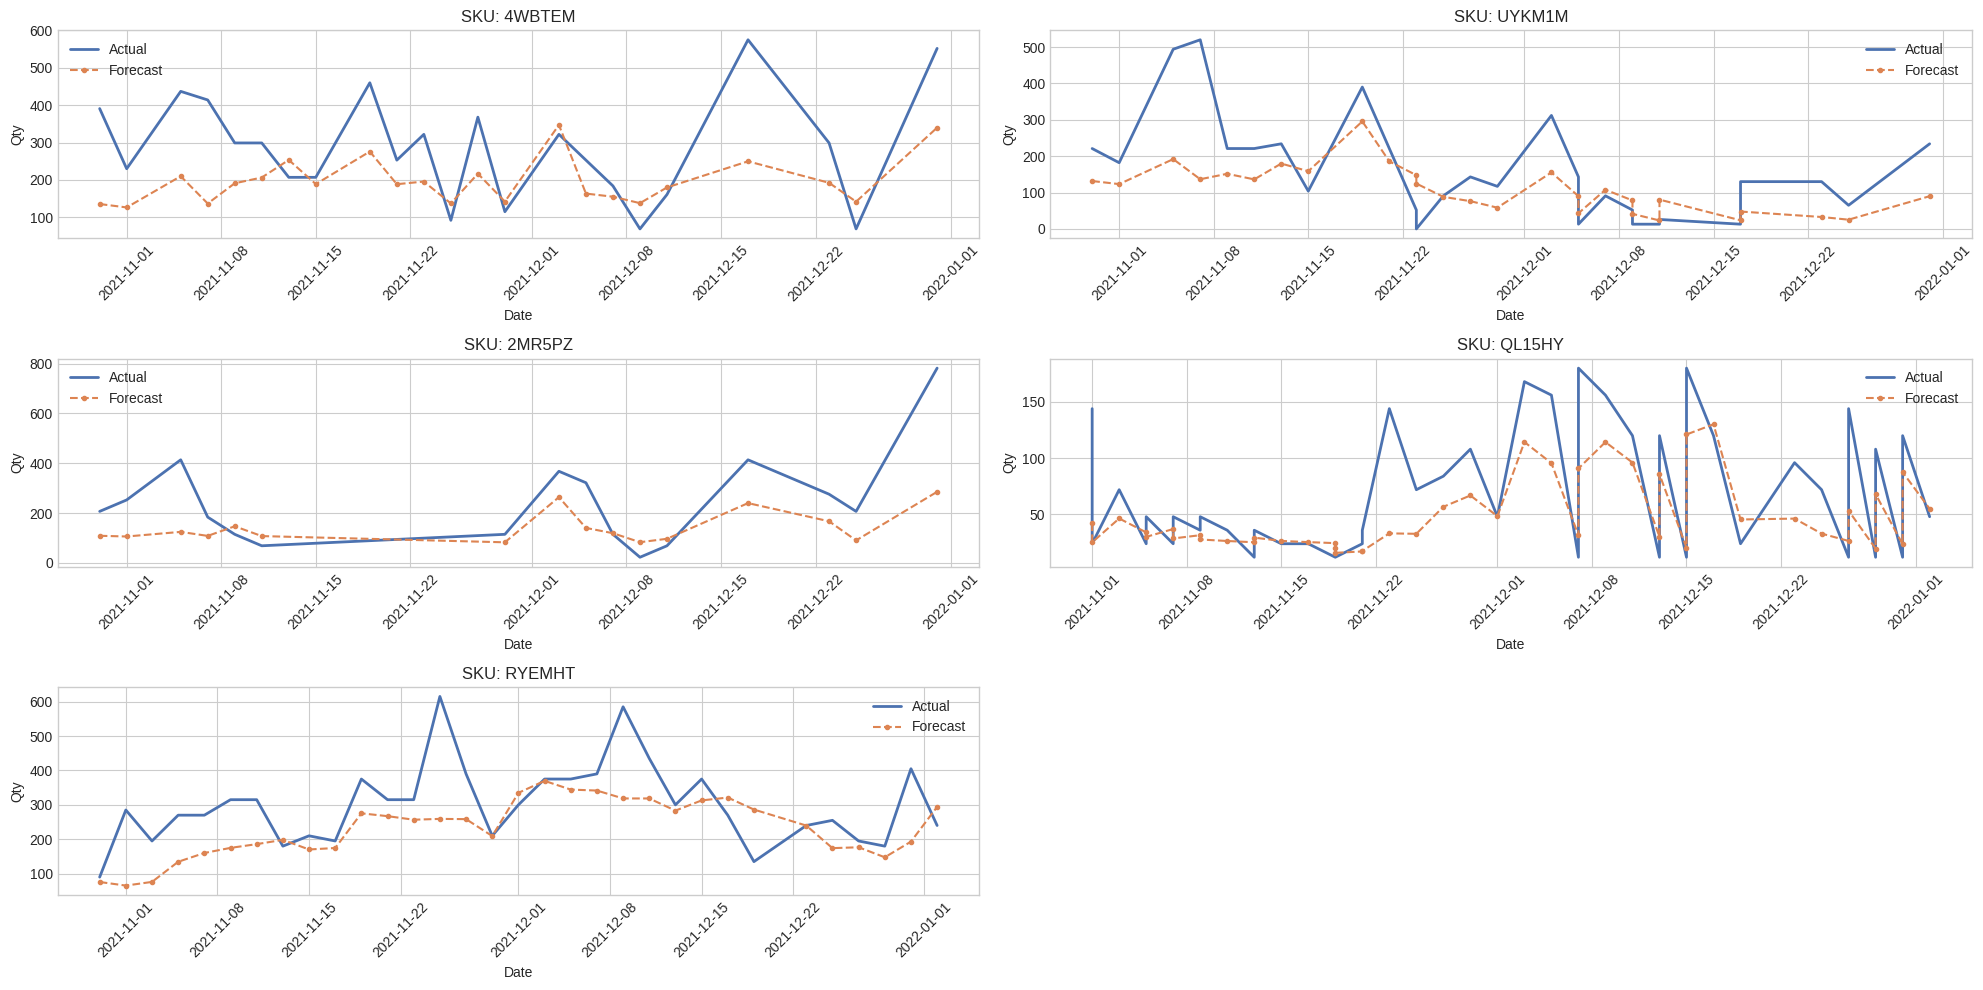

In [ ]:
sku_list = [
    "4WBTEM",
    "UYKM1M",
    "2MR5PZ",
    "QL15HY",
    "RYEMHT"
]

plot_sku_forecast(
    data=df_prediction,
    sku_list=sku_list,
    n_cols=2,
    figsize=(20, 10)
)

Explain model - SHAP:

In [ ]:
X_train_sample = X_train.sample(min(500, len(X_train)), random_state=42)
X_test_sample = X_test.sample(min(500, len(X_test)), random_state=42)
X_sample = pd.concat([X_train_sample, X_test_sample])

In [ ]:
explainer = shap.TreeExplainer(model)

In [ ]:
X_sample['channel'] = X_sample['channel'].astype('category')
shap_values = explainer.shap_values(X_sample)

Top 10 most important features globally:
           feature  importance
    rolling_mean_7    0.938036
           channel    0.139728
mean_qty_sku_month    0.097408
     rolling_std_7    0.091282
   rolling_mean_30    0.074212
              lag1    0.054953
         dayofweek    0.047948
        weekofyear    0.033102
        MOQ_orders    0.029910
               day    0.021587


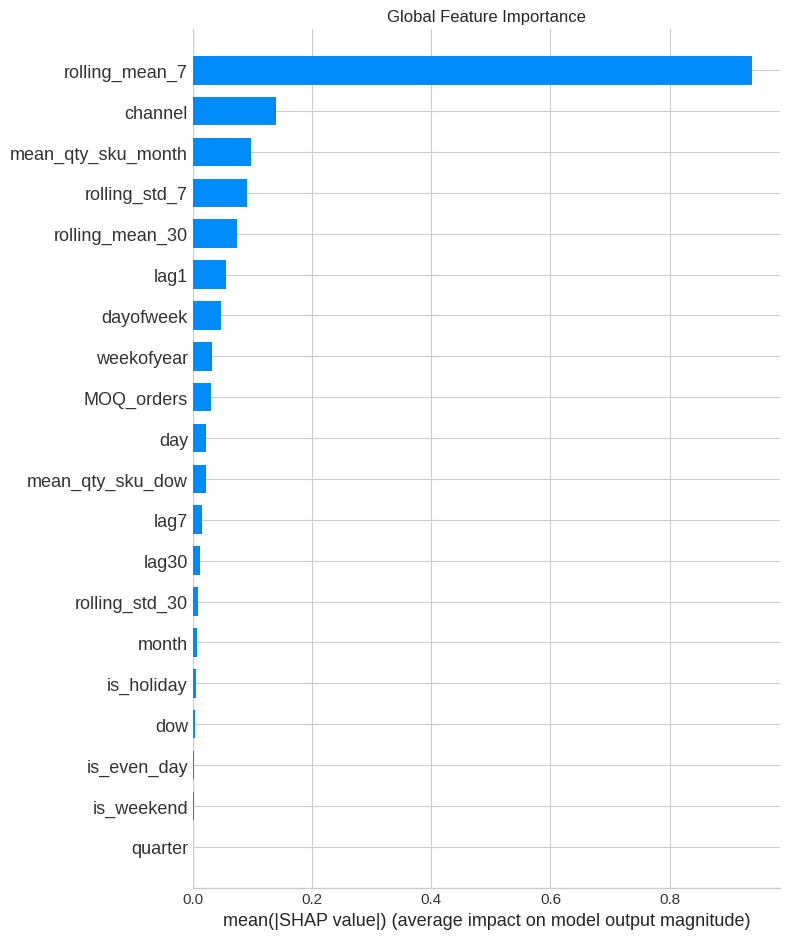

In [ ]:
print("Top 10 most important features globally:")
feature_importance = pd.DataFrame(
    {"feature": X_sample.columns, "importance": np.abs(shap_values).mean(axis=0)}
)
feature_importance = feature_importance.sort_values("importance", ascending=False)
print(feature_importance.head(10).to_string(index=False))

# Global feature importance plot
plt.figure(figsize=(12, 5))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("Global Feature Importance")
plt.tight_layout()

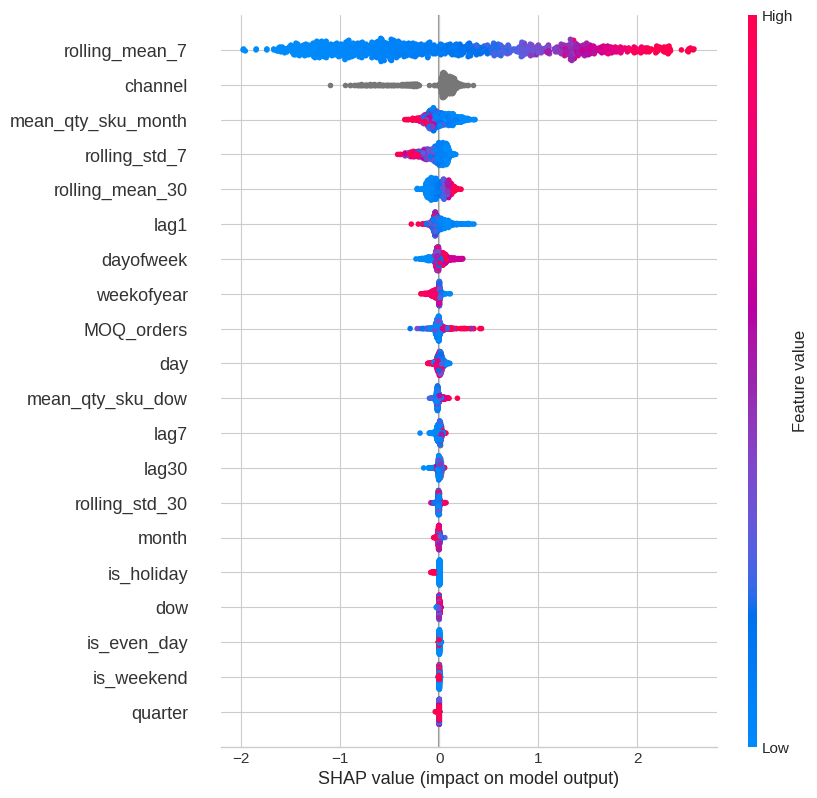

In [ ]:
shap.plots.beeswarm(explainer(X_sample), max_display=20)

In [ ]:
shap_values_valid = explainer(X_sample)

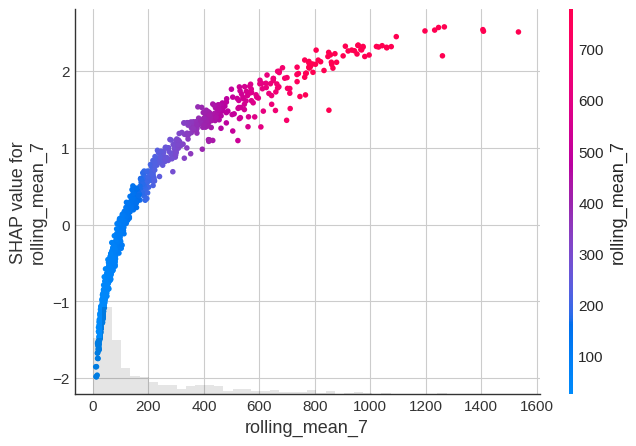

In [ ]:
feature_name = "rolling_mean_7"
shap.plots.scatter(shap_values_valid[:, feature_name], color=shap_values_valid[:, feature_name])

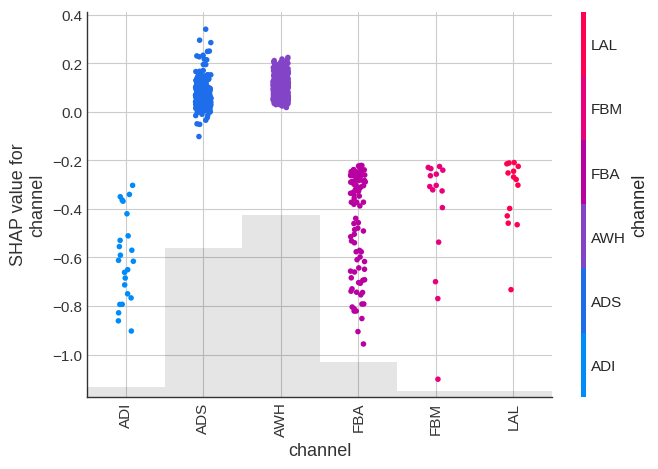

In [ ]:
feature_name = "channel"
shap.plots.scatter(shap_values_valid[:, feature_name], color=shap_values_valid[:, feature_name])

In [ ]:
sample_indices = X_test.sample(3, random_state=2025).index


Local explanation for 2021-12-03, SKU: UJEVZV
Actual sales: 64.00, Predicted: 47.02
Top factors increasing the prediction:
      feature   effect
    dayofweek 0.096404
rolling_std_7 0.083971
      channel 0.045465
          day 0.037023
   is_holiday 0.004261
Top factors decreasing the prediction:
           feature    effect
    rolling_mean_7 -0.681625
mean_qty_sku_month -0.055301
   rolling_mean_30 -0.054708
        weekofyear -0.039460
        MOQ_orders -0.024797

Local explanation for 2021-12-23, SKU: 8KTPVD
Actual sales: 20.00, Predicted: 63.38
Top factors increasing the prediction:
       feature   effect
rolling_mean_7 0.159699
       channel 0.096766
          lag1 0.017200
    is_holiday 0.005284
   is_even_day 0.001409
Top factors decreasing the prediction:
        feature    effect
rolling_mean_30 -0.168659
  rolling_std_7 -0.103405
     weekofyear -0.068681
      dayofweek -0.048758
            day -0.043296

Local explanation for 2021-12-25, SKU: 0YX29J
Actual sales: 5

<Figure size 1200x300 with 0 Axes>

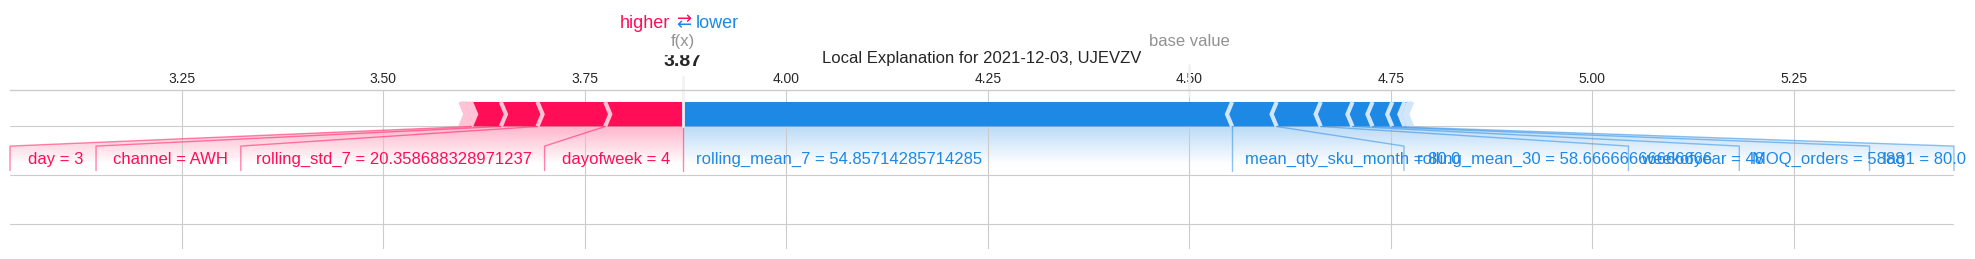

<Figure size 1200x300 with 0 Axes>

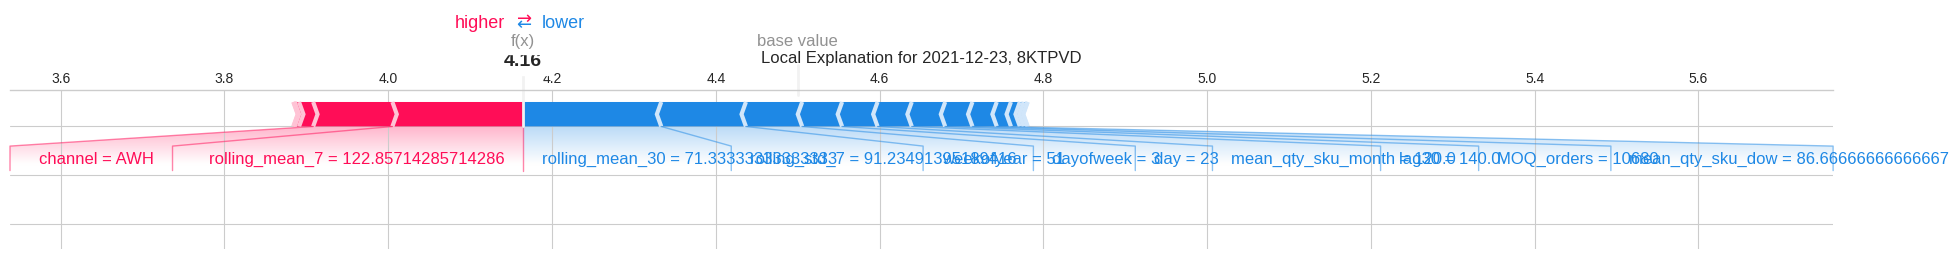

<Figure size 1200x300 with 0 Axes>

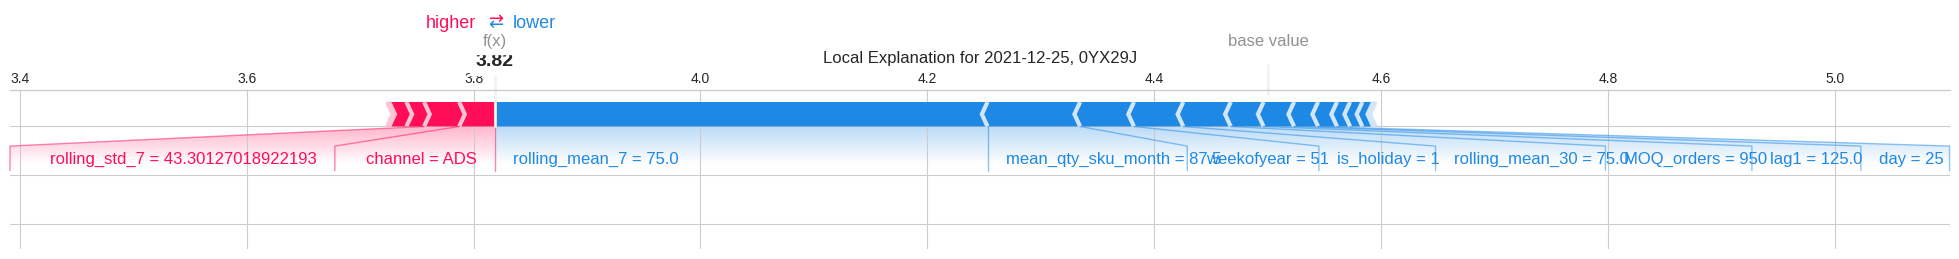

In [ ]:
for idx in sample_indices:
    sample = X_test.loc[idx:idx]
    sample_shap = explainer.shap_values(sample)[0]

    # Get sample metadata from test_results
    sample_info = test.loc[test.index == idx]
    sample_info['shipped_date'] = pd.to_datetime(sample_info['shipped_date'])
    if len(sample_info) > 0:
        date = sample_info["shipped_date"].iloc[0]
        sku = sample_info["sku"].iloc[0]
        actual = sample_info["qty"].iloc[0]
        predicted = sample_info["prediction"].iloc[0]

        print(
            f"\nLocal explanation for {date.strftime('%Y-%m-%d')}, SKU: {sku}"
        )
        print(f"Actual sales: {actual:.2f}, Predicted: {predicted:.2f}")

        # Top 5 factors increasing the prediction
        pos_factors = pd.DataFrame({"feature": sample.columns, "effect": sample_shap})
        pos_factors = pos_factors.sort_values("effect", ascending=False)
        print("Top factors increasing the prediction:")
        print(pos_factors.head(5).to_string(index=False))

        # Top 5 factors decreasing the prediction
        neg_factors = pd.DataFrame({"feature": sample.columns, "effect": sample_shap})
        neg_factors = neg_factors.sort_values("effect")
        print("Top factors decreasing the prediction:")
        print(neg_factors.head(5).to_string(index=False))

        # Force plot - a visualization of the local explanation
        plt.figure(figsize=(12, 3))
        shap.force_plot(
            explainer.expected_value, sample_shap, sample, matplotlib=True, show=False
        )
        plt.title(f'Local Explanation for {date.strftime("%Y-%m-%d")}, {sku}')
        plt.tight_layout()